# Рубежный контроль 1 по дисциплине Методы машинного обучения в автоматизированных системах

**Задания:**
- **Задача №2:** Target (mean) encoding категориального признака
- **Задача №22:** Масштабирование числового признака по максимальному значению
- **Доп. задание:** Скрипичная диаграмма (Violin Plot)

## Импорт библиотек и создание набора данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MaxAbsScaler

np.random.seed(42)

In [2]:
n = 250

brand_params = {
    'Toyota':   {'mean': 28000, 'std': 5000},
    'BMW':      {'mean': 65000, 'std': 12000},
    'Kia':      {'mean': 22000, 'std': 4000},
    'Mercedes': {'mean': 80000, 'std': 15000},
    'Hyundai':  {'mean': 24000, 'std': 4500},
}
brands = list(brand_params.keys())
brand_col = np.random.choice(brands, size=n, p=[0.25, 0.15, 0.20, 0.15, 0.25])

price_col = np.array([
    np.random.normal(brand_params[b]['mean'], brand_params[b]['std'])
    for b in brand_col
]).clip(5000, 150000)

df = pd.DataFrame({
    'brand':        brand_col,
    'mileage_km':   np.random.randint(0, 300000, size=n),
    'engine_vol':   np.round(np.random.choice([1.4, 1.6, 2.0, 2.5, 3.0, 4.0], size=n), 1),
    'horsepower':   np.random.randint(75, 500, size=n),
    'year':         np.random.randint(2005, 2024, size=n),
    'fuel_type':    np.random.choice(['Petrol', 'Diesel', 'Electric', 'Hybrid'], size=n,
                                     p=[0.45, 0.30, 0.10, 0.15]),
    'price_usd':    price_col.round(2),
})

print(f'Датасет создан: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Датасет создан: 250 строк, 7 столбцов


,brand,mileage_km,engine_vol,horsepower,year,fuel_type,price_usd
0,BMW,253490,2.5,381,2009,Hybrid,54838.48
1,Hyundai,43088,2.0,255,2006,Petrol,17183.19
2,Mercedes,247940,2.5,366,2015,Petrol,73302.28
3,Kia,216464,2.5,445,2013,Electric,25425.60
4,Toyota,218441,2.5,356,2007,Diesel,29070.47
5,Toyota,282107,2.5,103,2013,Diesel,21771.31
6,Toyota,125911,3.0,223,2007,Diesel,28865.90
7,Hyundai,223777,3.0,341,2006,Diesel,25733.93
8,Mercedes,276532,1.6,370,2016,Petrol,66742.14
9,Mercedes,5569,1.4,85,2014,Hybrid,82305.88


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   brand       250 non-null    object 
 1   mileage_km  250 non-null    int32  
 2   engine_vol  250 non-null    float64
 3   horsepower  250 non-null    int32  
 4   year        250 non-null    int32  
 5   fuel_type   250 non-null    object 
 6   price_usd   250 non-null    float64
dtypes: float64(2), int32(3), object(2)
memory usage: 10.9+ KB


In [4]:
df.describe()

,mileage_km,engine_vol,horsepower,year,price_usd
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,142567.660000,2.407200,286.820000,2014.112000,40220.150640
std,85607.301075,0.914293,122.931184,5.332655,23197.108192
min,846.000000,1.400000,77.000000,2005.000000,13899.430000
25%,70205.750000,1.600000,178.750000,2010.000000,24058.355000
50%,137244.000000,2.000000,298.500000,2014.500000,28447.175000
75%,218364.250000,3.000000,385.000000,2019.000000,60038.815000
max,296818.000000,4.000000,499.000000,2023.000000,98567.240000


---
## Задача №2 — Target (Mean) Encoding категориального признака

**Target encoding** (среднее по целевой переменной) заменяет каждую категорию числом — средним значением целевой переменной (`price_usd`) внутри этой категории.

**Выбранный признак:** `brand` (марка автомобиля)  
**Целевая переменная:** `price_usd` (цена автомобиля в USD)

In [5]:
target_col = 'price_usd'
cat_col    = 'brand'

mean_target_by_brand = df.groupby(cat_col)[target_col].mean()

print('Среднее значение price_usd по каждой марке:')
print(mean_target_by_brand.sort_values(ascending=False).round(2))

Среднее значение price_usd по каждой марке:
brand
Mercedes    76324.20
BMW         67023.54
Toyota      28637.30
Hyundai     24273.55
Kia         22726.52
Name: price_usd, dtype: float64


In [ ]:
df['brand_target_enc'] = df[cat_col].map(mean_target_by_brand)

print('Результат target encoding:')
df[['brand', 'price_usd', 'brand_target_enc']].head(15)

Результат target encoding:


,brand,price_usd,brand_target_enc
0,BMW,54838.48,67023.535000
1,Hyundai,17183.19,24273.547143
2,Mercedes,73302.28,76324.196410
3,Kia,25425.60,22726.524211
4,Toyota,29070.47,28637.303000
5,Toyota,21771.31,28637.303000
6,Toyota,28865.90,28637.303000
7,Hyundai,25733.93,24273.547143
8,Mercedes,66742.14,76324.196410
9,Mercedes,82305.88,76324.196410


In [ ]:
summary_te = (
    df.groupby('brand')
      .agg(
          count          = ('price_usd', 'count'),
          mean_price_usd = ('price_usd', 'mean'),
          target_enc_val = ('brand_target_enc', 'first')
      )
      .round(2)
      .sort_values('mean_price_usd', ascending=False)
)
print('Сводная таблица target encoding:')
summary_te

Сводная таблица target encoding:


,count,mean_price_usd,target_enc_val
brand,,,
Mercedes,39,76324.20,76324.20
BMW,40,67023.54,67023.54
Toyota,70,28637.30,28637.30
Hyundai,63,24273.55,24273.55
Kia,38,22726.52,22726.52


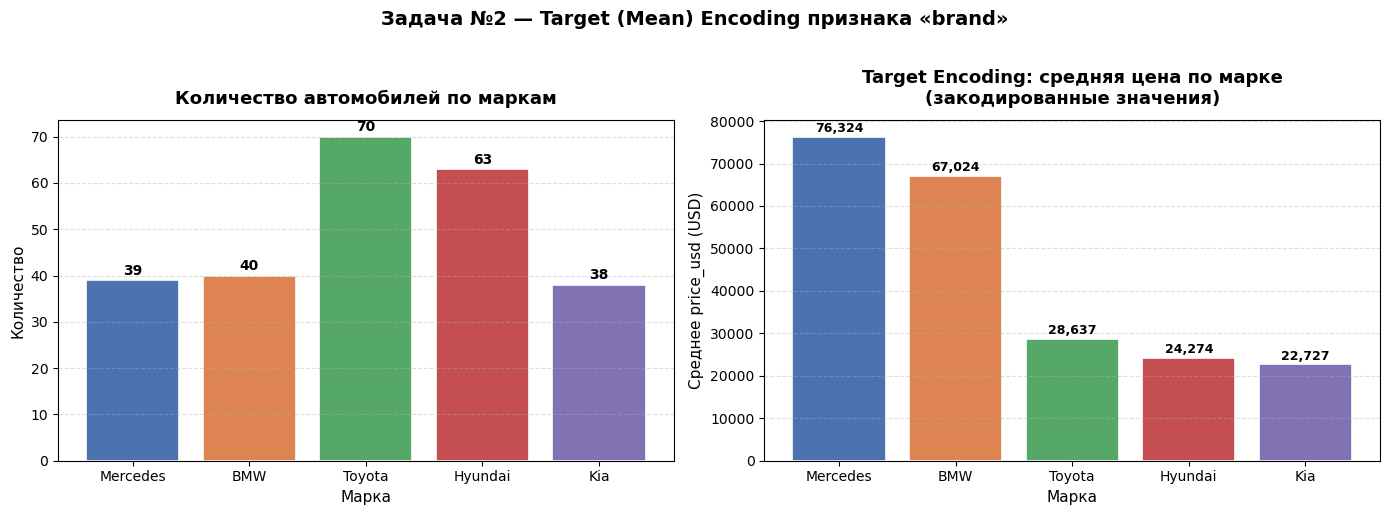


Вывод: категориальный признак «brand» заменён средним значением цены (price_usd)
для каждой категории. Метод позволяет сохранить информацию о целевой переменной.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brands_sorted = summary_te.index.tolist()
enc_values    = summary_te['target_enc_val'].tolist()
counts        = summary_te['count'].tolist()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

# --- График 1: Кол-во наблюдений по маркам ---
bars = axes[0].bar(brands_sorted, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Количество автомобилей по маркам', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Марка', fontsize=11)
axes[0].set_ylabel('Количество', fontsize=11)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- График 2: Target Encoded значения ---
bars2 = axes[1].bar(brands_sorted, enc_values, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Target Encoding: средняя цена по марке\n(закодированные значения)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Марка', fontsize=11)
axes[1].set_ylabel('Среднее price_usd (USD)', fontsize=11)
axes[1].grid(axis='y', alpha=0.4, linestyle='--')
for bar, val in zip(bars2, enc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Задача №2 — Target (Mean) Encoding признака «brand»',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nВывод: категориальный признак «brand» заменён средним значением цены (price_usd)')
print('для каждой категории. Метод позволяет сохранить информацию о целевой переменной.')

---
## Задача №22 — Масштабирование по максимальному значению (Max Scaling)

**Max Scaling** (масштабирование по максимуму) делит каждое значение признака на **максимальное абсолютное значение** в столбце, приводя данные к диапазону **[-1, 1]** (или [0, 1] для неотрицательных признаков).

$$x_{scaled} = \dfrac{x}{\max(|x|)}$$

**Выбранный признак:** `mileage_km` (пробег автомобиля в км)

In [ ]:
num_col = 'mileage_km'

print('=== Статистики ДО масштабирования ===')
print(df[num_col].describe().round(2))
print(f'\nМаксимальное значение: {df[num_col].max()}')

=== Статистики ДО масштабирования ===
count       250.00
mean     142567.66
std       85607.30
min         846.00
25%       70205.75
50%      137244.00
75%      218364.25
max      296818.00
Name: mileage_km, dtype: float64

Максимальное значение: 296818


In [ ]:
scaler = MaxAbsScaler()

mileage_values = df[[num_col]].values          
mileage_scaled = scaler.fit_transform(mileage_values)

df['mileage_km_maxscaled'] = mileage_scaled

print('=== Статистики ПОСЛЕ масштабирования ===')
print(df['mileage_km_maxscaled'].describe().round(6))
print(f'\nМасштабирующий множитель (max abs value): {scaler.max_abs_[0]:.0f}')

=== Статистики ПОСЛЕ масштабирования ===
count    250.000000
mean       0.480320
std        0.288417
min        0.002850
25%        0.236528
50%        0.462384
75%        0.735684
max        1.000000
Name: mileage_km_maxscaled, dtype: float64

Масштабирующий множитель (max abs value): 296818


In [ ]:
max_abs_val = df[num_col].abs().max()
df['mileage_km_manual'] = df[num_col] / max_abs_val

match = np.allclose(df['mileage_km_maxscaled'], df['mileage_km_manual'])
print(f'Результаты sklearn и ручного вычисления совпадают: {match}')

print('\nПервые 10 строк — сравнение исходных и масштабированных значений:')
df[['mileage_km', 'mileage_km_maxscaled']].head(10)

Результаты sklearn и ручного вычисления совпадают: True

Первые 10 строк — сравнение исходных и масштабированных значений:


,mileage_km,mileage_km_maxscaled
0,253490,0.854025
1,43088,0.145166
2,247940,0.835327
3,216464,0.729282
4,218441,0.735943
5,282107,0.950438
6,125911,0.424203
7,223777,0.753920
8,276532,0.931655
9,5569,0.018762


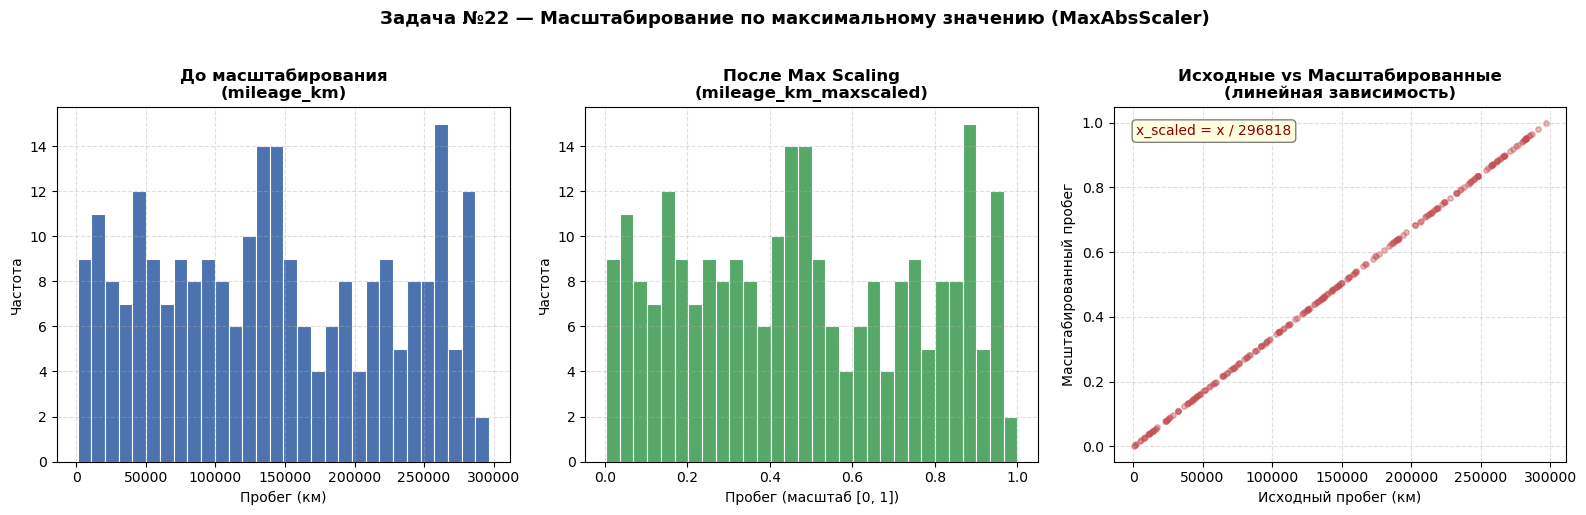

Вывод: признак «mileage_km» приведён к диапазону [0, 1] путём деления
каждого значения на максимальное абсолютное значение (296818 км).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Гистограмма до
axes[0].hist(df['mileage_km'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].set_title('До масштабирования\n(mileage_km)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Пробег (км)', fontsize=10)
axes[0].set_ylabel('Частота', fontsize=10)
axes[0].grid(alpha=0.4, linestyle='--')

# Гистограмма после
axes[1].hist(df['mileage_km_maxscaled'], bins=30, color='#55A868', edgecolor='white', linewidth=0.8)
axes[1].set_title('После Max Scaling\n(mileage_km_maxscaled)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Пробег (масштаб [0, 1])', fontsize=10)
axes[1].set_ylabel('Частота', fontsize=10)
axes[1].grid(alpha=0.4, linestyle='--')

# Scatter: исходные vs масштабированные (должна быть прямая)
axes[2].scatter(df['mileage_km'], df['mileage_km_maxscaled'],
                alpha=0.4, s=15, color='#C44E52')
axes[2].set_title('Исходные vs Масштабированные\n(линейная зависимость)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Исходный пробег (км)', fontsize=10)
axes[2].set_ylabel('Масштабированный пробег', fontsize=10)
axes[2].grid(alpha=0.4, linestyle='--')

# Аннотация формулы
formula = f'x_scaled = x / {max_abs_val:.0f}'
axes[2].annotate(formula, xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=10, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.suptitle('Задача №22 — Масштабирование по максимальному значению (MaxAbsScaler)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Вывод: признак «mileage_km» приведён к диапазону [0, 1] путём деления')
print(f'каждого значения на максимальное абсолютное значение ({max_abs_val:.0f} км).')

---
## Дополнительное задание — Скрипичная диаграмма (Violin Plot)

Скрипичная диаграмма объединяет **ящик с усами (box plot)** и **оценку плотности вероятности (KDE)**, что позволяет видеть не только медиану и квартили, но и полное распределение данных.

**Визуализируем:** распределение `horsepower` (мощность в л.с.) по маркам автомобилей.

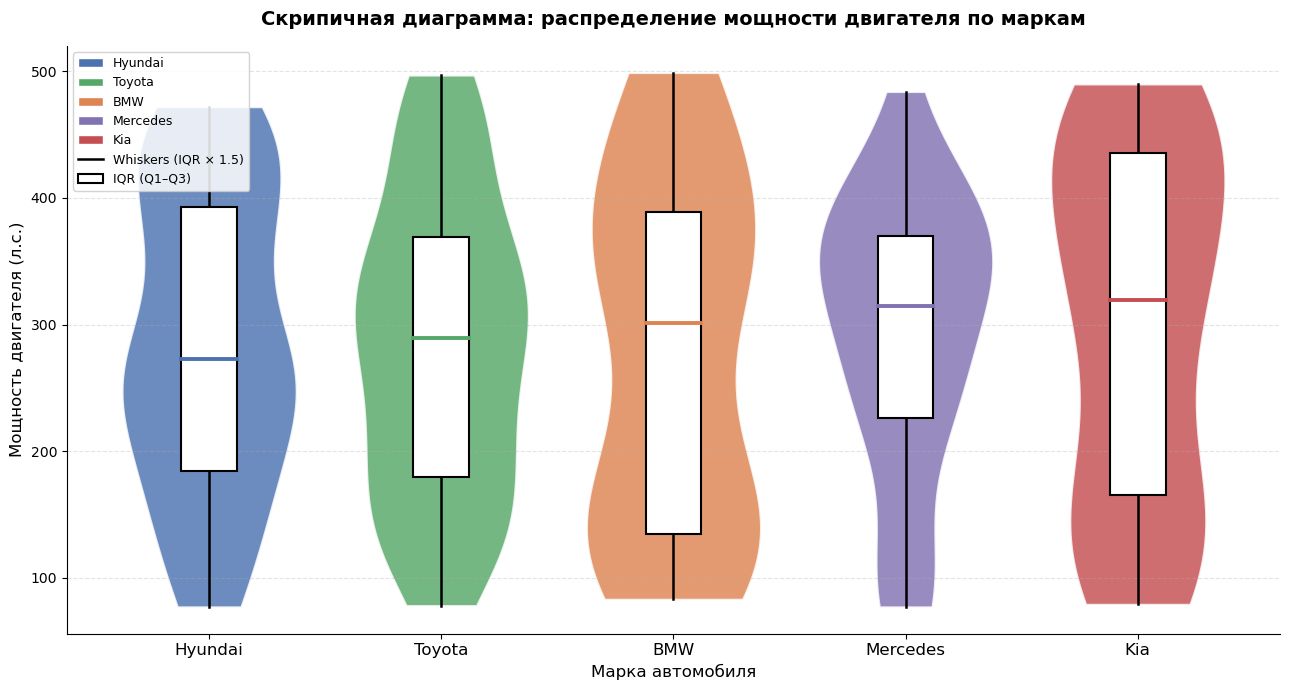

Вывод: скрипичная диаграмма показывает полное распределение мощности
двигателя для каждой марки — форму распределения, медиану, IQR и выбросы.


In [ ]:
brand_order = df.groupby('brand')['horsepower'].median().sort_values().index.tolist()
data_by_brand = [df[df['brand'] == b]['horsepower'].values for b in brand_order]

fig, ax = plt.subplots(figsize=(13, 7))

palette = ['#4C72B0', '#55A868', '#DD8452', '#8172B3', '#C44E52']

# Скрипичные контуры
vp = ax.violinplot(
    data_by_brand,
    positions=range(1, len(brand_order) + 1),
    showmedians=False,
    showextrema=False,
    widths=0.75
)

# Раскраска каждой «скрипки»
for i, (body, color) in enumerate(zip(vp['bodies'], palette)):
    body.set_facecolor(color)
    body.set_edgecolor('white')
    body.set_alpha(0.82)
    body.set_linewidth(1.5)

# Поверх — box plot (IQR + медиана)
for i, (data, color) in enumerate(zip(data_by_brand, palette)):
    pos  = i + 1
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    iqr_lo = max(data[data >= q1 - 1.5 * (q3 - q1)].min(), data.min())
    iqr_hi = min(data[data <= q3 + 1.5 * (q3 - q1)].max(), data.max())

    # Усы
    ax.plot([pos, pos], [iqr_lo, iqr_hi], color='black', linewidth=1.8, zorder=3)
    # IQR-прямоугольник
    ax.add_patch(plt.Rectangle((pos - 0.12, q1), 0.24, q3 - q1,
                                facecolor='white', edgecolor='black',
                                linewidth=1.5, zorder=4))
    # Медиана
    ax.plot([pos - 0.12, pos + 0.12], [med, med],
            color=color, linewidth=2.8, zorder=5)

    # Выбросы
    outliers = data[(data < iqr_lo) | (data > iqr_hi)]
    if len(outliers):
        ax.scatter([pos] * len(outliers), outliers,
                   color=color, s=22, zorder=6, alpha=0.7, edgecolors='black', linewidths=0.5)

# Оформление
ax.set_xticks(range(1, len(brand_order) + 1))
ax.set_xticklabels(brand_order, fontsize=12)
ax.set_xlabel('Марка автомобиля', fontsize=12)
ax.set_ylabel('Мощность двигателя (л.с.)', fontsize=12)
ax.set_title('Скрипичная диаграмма: распределение мощности двигателя по маркам',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Легенда
legend_elements = [
    mpatches.Patch(facecolor=c, edgecolor='white', label=b)
    for c, b in zip(palette, brand_order)
]
legend_elements += [
    plt.Line2D([0], [0], color='black', linewidth=1.8, label='Whiskers (IQR × 1.5)'),
    plt.Rectangle((0, 0), 1, 1, fc='white', ec='black', lw=1.5, label='IQR (Q1–Q3)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.show()

print('Вывод: скрипичная диаграмма показывает полное распределение мощности')
print('двигателя для каждой марки — форму распределения, медиану, IQR и выбросы.')

---
## Итоговый датасет (все преобразования)

In [14]:
result_cols = ['brand', 'mileage_km', 'horsepower', 'year',
               'price_usd', 'brand_target_enc', 'mileage_km_maxscaled']

print('Итоговый датасет с добавленными признаками:')
df[result_cols].head(12).style.format({
    'price_usd':           '{:,.2f}',
    'brand_target_enc':    '{:,.2f}',
    'mileage_km_maxscaled': '{:.6f}'
})

Итоговый датасет с добавленными признаками:


,brand,mileage_km,horsepower,year,price_usd,brand_target_enc,mileage_km_maxscaled
0,BMW,253490,381,2009,"54,838.48","67,023.54",0.854025
1,Hyundai,43088,255,2006,"17,183.19","24,273.55",0.145166
2,Mercedes,247940,366,2015,"73,302.28","76,324.20",0.835327
3,Kia,216464,445,2013,"25,425.60","22,726.52",0.729282
4,Toyota,218441,356,2007,"29,070.47","28,637.30",0.735943
5,Toyota,282107,103,2013,"21,771.31","28,637.30",0.950438
6,Toyota,125911,223,2007,"28,865.90","28,637.30",0.424203
7,Hyundai,223777,341,2006,"25,733.93","24,273.55",0.753920
8,Mercedes,276532,370,2016,"66,742.14","76,324.20",0.931655
9,Mercedes,5569,85,2014,"82,305.88","76,324.20",0.018762


---
## Выводы

| Задача | Метод | Признак | Результат |
|--------|-------|---------|----------|
| №2 | Target (Mean) Encoding | `brand` | `brand_target_enc` — среднее `price_usd` по марке |
| №22 | Max Scaling (MaxAbsScaler) | `mileage_km` | `mileage_km_maxscaled` ∈ [0, 1] |
| Доп. | Violin Plot | `horsepower` по `brand` | Визуализация распределения мощности |

**Target Encoding** эффективен при большом числе категорий и высокой корреляции категориального признака с целевой переменной. Следует учитывать риск переобучения — рекомендуется использовать кросс-валидационную схему в реальных проектах.

**Max Scaling** сохраняет нулевые значения и разреженность данных, не смещает распределение — оптимален для разреженных признаков и алгоритмов, чувствительных к масштабу.